# Titanic Data Cleaning and Visualization

## Objective

In this notebook, we will:

- Load the Titanic dataset
- Explore the data
- Handle missing values
- Detect outliers
- Create visualizations
- Identify which feature most affects survival

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots nicely
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
df = pd.read_csv("train.csv")


In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 891
Columns: 12


In [7]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling Missing Values

- The **Age** column contains many missing values, so I filled them using the **median**, which is less affected by extreme values.
- The **Embarked** column has only two missing values, so I filled them with the most frequent value (mode).
- The **Cabin** column contains too many missing values (over 75%), so I removed it because it would not contribute meaningful information for this analysis.

In [8]:
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin column
df.drop(columns=["Cabin"], inplace=True)


In [9]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

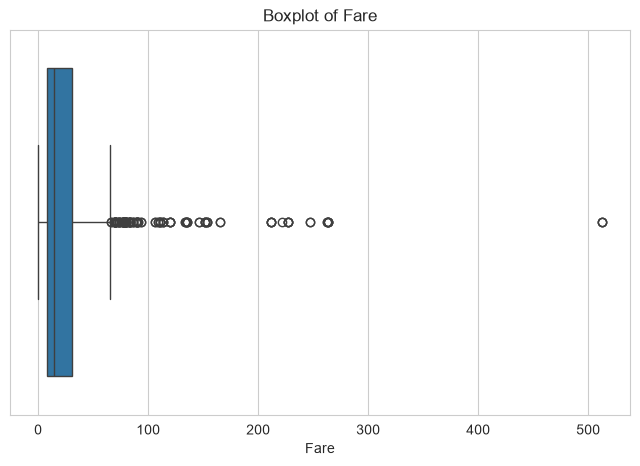

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Fare")
plt.xlabel("Fare")

plt.show()


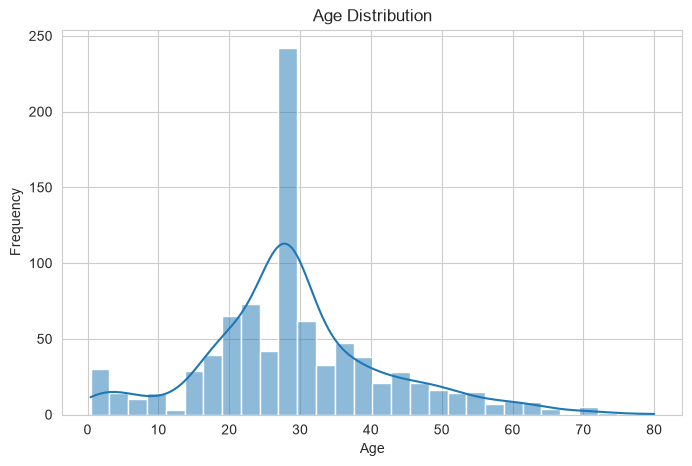

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


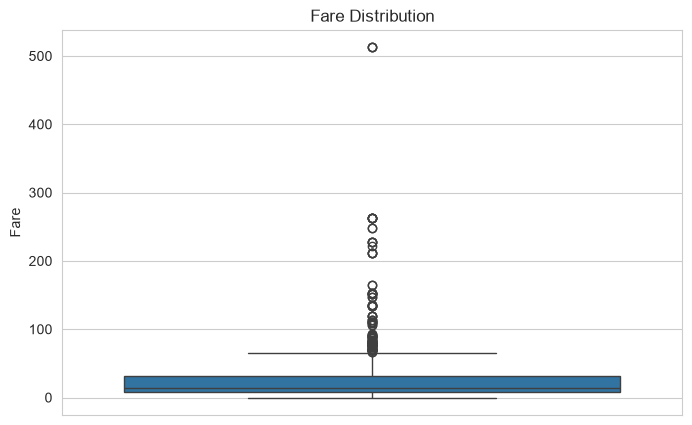

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Fare"])

plt.title("Fare Distribution")

plt.show()


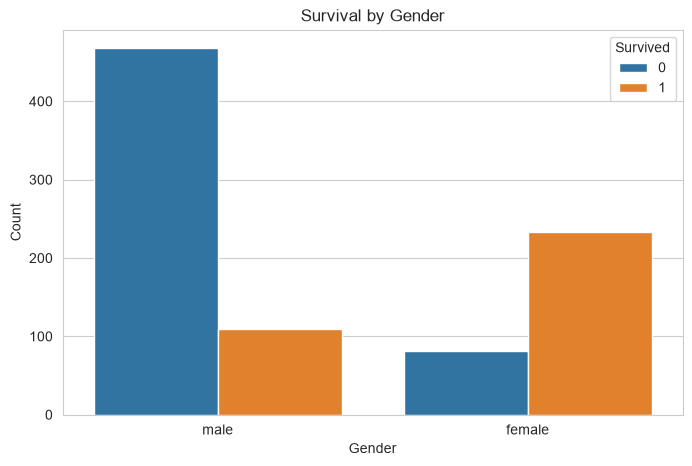

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


In [14]:
heatmap_df = df.copy()

heatmap_df["Sex"] = heatmap_df["Sex"].map({"male": 0, "female": 1})

heatmap_df["Embarked"] = heatmap_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})


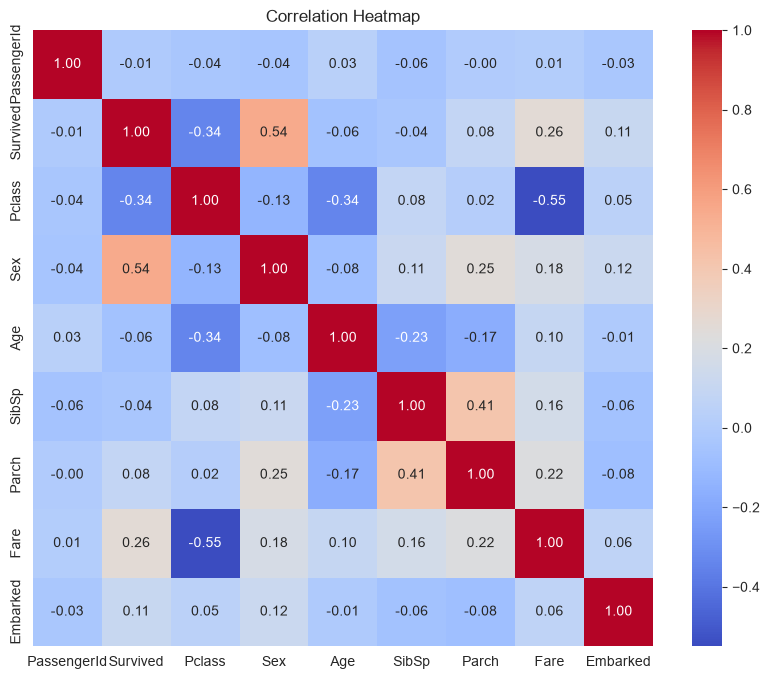

In [15]:
plt.figure(figsize=(10, 8))

sns.heatmap(heatmap_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()


# Which Feature Most Affects Survival?

From the visualizations, **Sex** appears to have the strongest effect on survival. Female passengers survived at a much higher rate than male passengers, which reflects the historical evacuation policy of prioritizing women and children.

Passenger class (**Pclass**) also has a noticeable influence, with first-class passengers generally having better survival rates than those in lower classes.

These observations suggest that both gender and passenger class were important factors during the Titanic disaster.

In [16]:
print("=" * 40)
print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nNumerical Columns")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical Columns")
print(df.select_dtypes(include=["object"]).columns.tolist())
print("=" * 40)


Dataset Shape: (891, 11)

Missing Values
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Numerical Columns
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns
['Name', 'Sex', 'Ticket', 'Embarked']


C:\Users\faiz\AppData\Local\Temp\ipykernel_14656\1059814758.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=["object"]).columns.tolist())
